# **Tabela Hash**

## **1. O que é uma tabela hash**

Uma `tabela hash` (hash table) é uma estrutura de dados que associa **chaves a valores**, projetada para fornecer inserção, busca e remoção em tempo médio `O(1)`.

É utilizada uma `função hash` para calcular diretamente a posição (índice) onde o valor deve estar armazenado em um vetor.

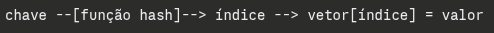

In [91]:
hash_table = dict()

hash_table['chave'] = 'valor'

print(hash_table)

{'chave': 'valor'}


## **2. Função hash**

É responsável por transformar uma chave em um número inteiro (`hash code`), que depois é mapeado para um índice válido do vetor.

- função_hash(chave) = índice

A forma mais comum de comprimir o hash code é utilizando o módulo:

- índice = hash_code % len(array)

Uma boa função hash deve ser **consistente** (mesma chave sempre gera o mesmo índice) e **distribuir bem os dados** (chaves diferentes devem se espalhar uniformemente pelos índices, minimizando colições).

### **Exemplos de funções hash**

In [92]:
def hash_function(chave, tamanho_tabela):

    """Função hash simples baseada na soma dos códigos ASCII."""

    hash_code = 0

    for i in chave:

        hash_code += ord(i)

    return hash_code % tamanho_tabela

print(hash_function('Guthierry', 10))
print(hash_function('Elis', 10))
print(hash_function('Elen', 10))

3
7
8


In [93]:
def hash_function(chave, tamanho_tabela):

    """Função hash simples baseada no tamanho da chave."""

    hash_code = len(chave)

    return hash_code % tamanho_tabela

print(hash_function('Guthierry', 10))
print(hash_function('Elis', 10))
print(hash_function('Elen', 10))

9
4
4


In [94]:
def hash_function(chave, tamanho_tabela):

    """Função hash simples baseada no hash code gerado pela função hash."""

    hash_code = hash(chave)

    return hash_code % tamanho_tabela

print(hash_function('Guthierry', 10))
print(hash_function('Elis', 10))
print(hash_function('Elen', 10))

8
1
6


## **3. Colisões**

Colisão ocorre quando duas chaves diferentes geram o mesmo índice. Uma estratégia para tratar colisões é o `Encadeamento`.

**Encadeamento**: Cada posição do vetor armazena uma lista encadeada com os elementos que sofreram colisão naquele índice.

## **4. Fator de carga**

O fator de carga mede o quão cheia está a tabela:

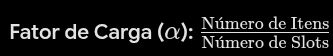

- `fator de carga baixo` -> poucas colisões, boa performance, mas desperdício de memória.

- `fator de carga alto` -> mais colisões, degradando o desempenho.

**Redimensionamento**: Quando o fator de carga ultrapassa um limite (Ex: 0.7), a tabela é `redimensionada` - normalmente dobrando o tamanho do vetor - e todos os elementos são reinseridos com os novos índices.

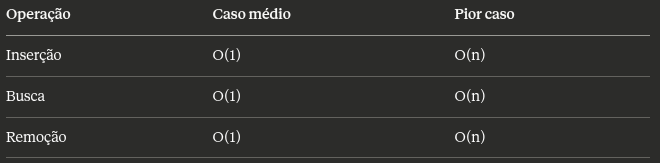

## **Tabela Hash Completa**

In [95]:
[[(), ()], [], []]

[[(), ()], [], []]

In [96]:
class TabelaHash:

    def __init__(self, size):
        self._size = size
        self._tabela = [[] for _ in range(self._size)]

    def _hash_function(self, chave):

        hash_code = hash(chave)

        return hash_code % self._size

    def add(self, chave, valor):
        
        idx = self._hash_function(chave)

        for i, (k, v) in enumerate(self._tabela[idx]):

            if k == chave:

                self._tabela[idx][i] = (chave, valor)
                return

        self._tabela[idx].append((chave, valor))
        return


    def get(self, chave, defaut = None):
        
        idx = self._hash_function(chave)

        for (k, v) in self._tabela[idx]: 

            if k == chave:

                return v
            
        return defaut

    def delete(self, chave):
        
        idx = self._hash_function(chave)

        self._tabela[idx] = [(k,v) for k,v in self._tabela[idx] if k != chave]
        
    def visualise(self):
        
        print(self._tabela)

In [97]:
hashmap = TabelaHash(10)

hashmap.add('guthy', 10)
hashmap.add('elis', 6)
hashmap.add('elen', 3)

hashmap.visualise()

hashmap.add('guthy', 8)

hashmap.visualise()

print(hashmap.get('elis'))
hashmap.delete('elen')
hashmap.delete('guthy')

hashmap.visualise()

hashmap.add('guthy', 8)
hashmap.visualise()

print(hashmap.get('sanchez'))

[[('elis', 6), ('elen', 3)], [('guthy', 10)], [], [], [], [], [], [], [], []]
[[('elis', 6), ('elen', 3)], [('guthy', 8)], [], [], [], [], [], [], [], []]
6
[[('elis', 6)], [], [], [], [], [], [], [], [], []]
[[('elis', 6)], [('guthy', 8)], [], [], [], [], [], [], [], []]
None


In [98]:
# Tabela hash com redimensionamento

class TabelaHash:

    def __init__(self, size):
        self._size = size
        self._tabela = [[] for _ in range(self._size)]

    def _hash_function(self, chave):

        hash_code = hash(chave)

        return hash_code % self._size

    def add(self, chave, valor):
        
        idx = self._hash_function(chave)

        for i, (k, v) in enumerate(self._tabela[idx]):

            if k == chave:

                self._tabela[idx][i] = (chave, valor)
                return

        self._tabela[idx].append((chave, valor))
        
        if self._load_factor() >= 0.7:

            self._tabela = self._resized()

    def get(self, chave, defaut = None):
        
        idx = self._hash_function(chave)

        for (k, v) in self._tabela[idx]: 

            if k == chave:

                return v
            
        return defaut

    def delete(self, chave):
        
        idx = self._hash_function(chave)

        self._tabela[idx] = [(k,v) for k,v in self._tabela[idx] if k != chave]

    def _resized(self):

        self._size = self._size * 2

        tabela = self._tabela

        self._tabela = [[] for _ in range(self._size)]

        for bucket in tabela:

            for chave, valor in bucket:

                idx = self._hash_function(chave)

                self._tabela[idx].append((chave, valor))

        return self._tabela

    def _load_factor(self):

        counts = 0

        for bucket in self._tabela:

            counts += len(bucket)

        return (counts / self._size)
        
    def visualise(self):
        print(f"Tamanho atual do array: {self._size} | Fator de Carga: {self._load_factor():.2f}")
        print(self._tabela)

In [99]:
hashmap = TabelaHash(5)

hashmap.add('guthy', 10)
hashmap.add('elis', 6)
hashmap.add('elen', 3)

In [100]:
hashmap.visualise()

Tamanho atual do array: 5 | Fator de Carga: 0.60
[[('elis', 6), ('elen', 3)], [('guthy', 10)], [], [], []]


In [101]:
hashmap.add('xablau', 5)

In [102]:
hashmap.visualise()

Tamanho atual do array: 10 | Fator de Carga: 0.40
[[('elis', 6), ('elen', 3)], [('guthy', 10)], [], [('xablau', 5)], [], [], [], [], [], []]


In [103]:
hashmap.add('xiquexique', 34)

In [104]:
hashmap.visualise()

Tamanho atual do array: 10 | Fator de Carga: 0.50
[[('elis', 6), ('elen', 3)], [('guthy', 10)], [], [('xablau', 5)], [], [], [], [], [('xiquexique', 34)], []]


## **Recapitulando**

- Uma tabela hash é feita combinando uma função hash com um array.

- É necessário haver uma função hash que minimize colisões.

- As tabelas hash são extremamente rápidas rápidas para pesquisar, inserir e remover itens. **O(1)**

- Tabelas hash são boas para modelar relações entre dois itens.

- Se o fator de carga for maior que 0,7, será necessário redimensionar a sua tabela hash.